# Regresión — experimentar con otros modelos

En el cuaderno anterior usamos un modelo de regresión lineal simple. Aquí probamos modelos más complejos para intentar superar ese baseline.

La celda siguiente repite la carga y la división de datos, con la **misma semilla** (`random_state=0`) para que la comparación sea justa: mismos datos de entrenamiento y de prueba que en el baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset
bike_data = pd.read_csv('../datasets/daily-bike-share.csv')
bike_data['day'] = pd.DatetimeIndex(bike_data['dteday']).day

# Separar features y labels
X, y = bike_data[['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
                  'temp', 'atemp', 'hum', 'windspeed']].values, bike_data['rentals'].values

# Misma división que en el baseline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print(f'Entrenamiento: {X_train.shape[0]} filas · Prueba: {X_test.shape[0]} filas')

Entrenamiento: 511 filas · Prueba: 220 filas


## Una función para no repetir código

Los cuatro modelos que vamos a probar se evalúan exactamente igual. En vez de copiar y pegar el bloque de métricas cuatro veces, lo encapsulamos una vez.

Este es el patrón importante: cuando pruebas varios modelos, lo único que cambia es el **estimador**; todo lo demás (entrenar, predecir, medir, graficar) es idéntico.

In [2]:
resultados = []

def evaluar(model, nombre, mostrar_grafico=True):
    """Entrena, evalúa y grafica un modelo. Devuelve sus métricas."""
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f'--- {nombre} ---')
    print(f'MAE : {mae:.4f}')
    print(f'MSE : {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2  : {r2:.4f}\n')

    if mostrar_grafico:
        plt.scatter(y_test, predictions)
        plt.xlabel('Labels reales')
        plt.ylabel('Labels predichos')
        plt.title(nombre)
        z = np.polyfit(y_test, predictions, 1)
        p = np.poly1d(z)
        plt.plot(y_test, p(y_test), color='magenta')
        plt.show()

    resultados.append({'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return model

## Baseline: regresión lineal

Primero reproducimos el baseline del cuaderno anterior, para tenerlo en la misma tabla comparativa.

--- LinearRegression (baseline) ---
MAE : 322.9976
MSE : 201972.5595
RMSE: 449.4136
R2  : 0.6040



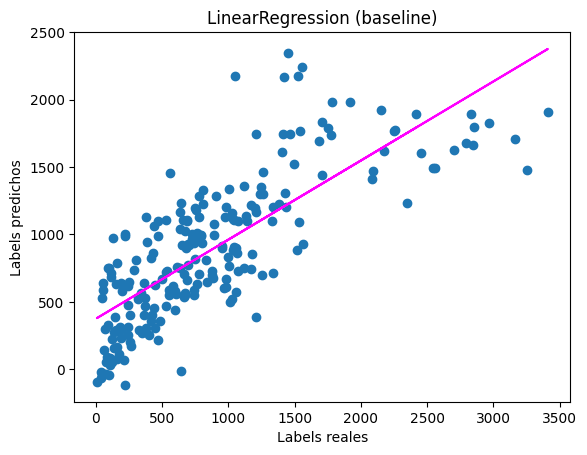

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 71.75, -14.6 , -315.71,..., -32.69, -553.32,-1229.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,985.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[81.18,44.4 ,12.77,..., 2.37, 1.56, 0.38]"


In [3]:
from sklearn.linear_model import LinearRegression

evaluar(LinearRegression(), 'LinearRegression (baseline)')

## Qué otros algoritmos existen

El algoritmo de regresión lineal tiene cierta capacidad predictiva, pero hay muchas familias de algoritmos de regresión:

- **Lineales**: no solo `LinearRegression` (que técnicamente es *mínimos cuadrados ordinarios*), sino variantes como **Lasso** y **Ridge**.
- **Basados en árboles**: construyen un árbol de decisión para llegar a una predicción.
- **De conjunto (ensemble)**: combinan las salidas de varios modelos base para mejorar la generalización.

### Otro algoritmo lineal: Lasso

Cambiar de algoritmo es literalmente cambiar el estimador. Todo lo demás queda igual.

--- Lasso ---
MAE : 320.5981
MSE : 201155.7059
RMSE: 448.5039
R2  : 0.6056



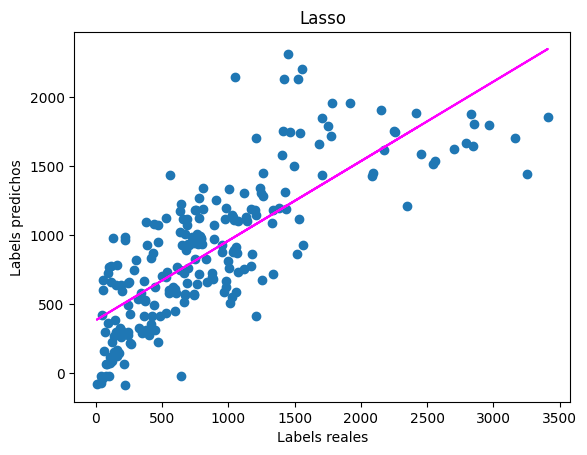

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [4]:
from sklearn.linear_model import Lasso

evaluar(Lasso(), 'Lasso')

### Árbol de decisión

Alternativa a los modelos lineales: examinar las features en una serie de evaluaciones, cada una de las cuales produce una **rama** del árbol según el valor de la feature. Al final de cada serie de ramas hay nodos hoja con el valor predicho.

Entrenemos uno y veamos su estructura.

In [5]:
from sklearn.tree import DecisionTreeRegressor, export_text

modelo_arbol = DecisionTreeRegressor(random_state=0)
modelo_arbol.fit(X_train, y_train)

print(f'Profundidad del árbol completo: {modelo_arbol.get_depth()} niveles')
print(f'Nodos hoja: {modelo_arbol.get_n_leaves()}\n')

# El árbol completo tiene cientos de nodos: imprimirlo entero no se puede leer.
# Mostramos solo los 3 primeros niveles para ver la lógica de las ramas.
print(export_text(modelo_arbol, max_depth=3))

Profundidad del árbol completo: 20 niveles
Nodos hoja: 508

|--- feature_6 <= 0.45
|   |--- feature_4 <= 0.50
|   |   |--- feature_7 <= 0.32
|   |   |   |--- feature_8 <= 0.41
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- feature_8 >  0.41
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- feature_7 >  0.32
|   |   |   |--- feature_9 <= 0.25
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- feature_9 >  0.25
|   |   |   |   |--- truncated branch of depth 5
|   |--- feature_4 >  0.50
|   |   |--- feature_6 <= 0.34
|   |   |   |--- feature_1 <= 2.50
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- feature_1 >  2.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |--- feature_6 >  0.34
|   |   |   |--- feature_3 <= 4.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- feature_3 >  4.50
|   |   |   |   |--- truncated branch of depth 7
|--- feature_6 >  0.45
|   |--- feature_4 <= 0.50
|   |   |--- f

> **Nota**: el ejercicio original imprime el árbol completo. Como este árbol crece sin poda hasta cientos de niveles, aquí lo limitamos a 3 niveles — lo interesante es ver **cómo ramifica**, no leer miles de líneas.
>
> Fíjate en la lógica: cada línea es una pregunta del tipo "¿la feature X está por debajo de tal valor?", y bajando por las ramas se llega a un valor predicho.

Ahora evaluémoslo.

--- DecisionTreeRegressor ---
MAE : 316.1227
MSE : 237843.9955
RMSE: 487.6925
R2  : 0.5337



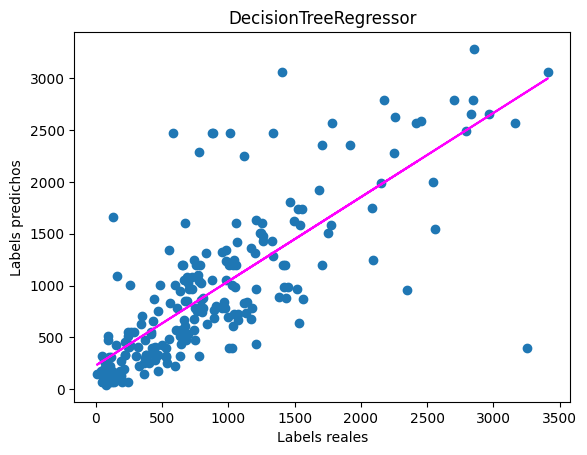

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [6]:
evaluar(DecisionTreeRegressor(random_state=0), 'DecisionTreeRegressor')

El modelo basado en árbol no mejora significativamente al lineal. ¿Qué más se puede probar?

### Algoritmos de conjunto (ensemble)

Combinan varios estimadores base para producir un modelo mejor. Hay dos estrategias:

- **Bagging**: construir muchos modelos de forma **independiente** y promediar sus resultados.
- **Boosting**: construir modelos en **secuencia**, donde cada uno intenta corregir el error del anterior.

Empecemos con un **Random Forest**, que aplica una función de promedio sobre múltiples árboles de decisión (bagging).

--- RandomForestRegressor ---
MAE : 243.7807
MSE : 117385.1555
RMSE: 342.6152
R2  : 0.7699



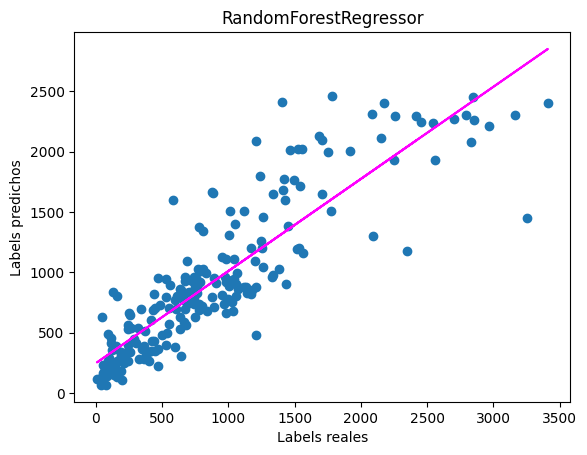

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [7]:
from sklearn.ensemble import RandomForestRegressor

evaluar(RandomForestRegressor(random_state=0), 'RandomForestRegressor')

Ahora un algoritmo de **boosting**: `GradientBoostingRegressor`. Igual que Random Forest construye muchos árboles, pero en vez de construirlos todos de forma independiente y promediar, **cada árbol se construye sobre las salidas del anterior**, intentando reducir la pérdida de forma incremental.

--- GradientBoostingRegressor ---
MAE : 228.4757
MSE : 103872.8172
RMSE: 322.2931
R2  : 0.7964



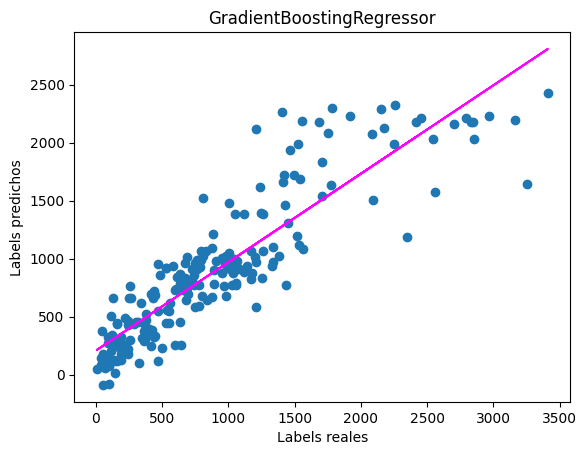

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

evaluar(GradientBoostingRegressor(random_state=0), 'GradientBoostingRegressor')

## Comparativa

Ahora que están todos en la misma tabla, se ve cuál gana:

In [9]:
df_resultados = pd.DataFrame(resultados).sort_values('R2', ascending=False).reset_index(drop=True)
df_resultados.round(4)

,modelo,MAE,RMSE,R2
0,GradientBoostingRegressor,228.4757,322.2931,0.7964
1,RandomForestRegressor,243.7807,342.6152,0.7699
2,Lasso,320.5981,448.5039,0.6056
3,LinearRegression (baseline),322.9976,449.4136,0.6040
4,DecisionTreeRegressor,316.1227,487.6925,0.5337


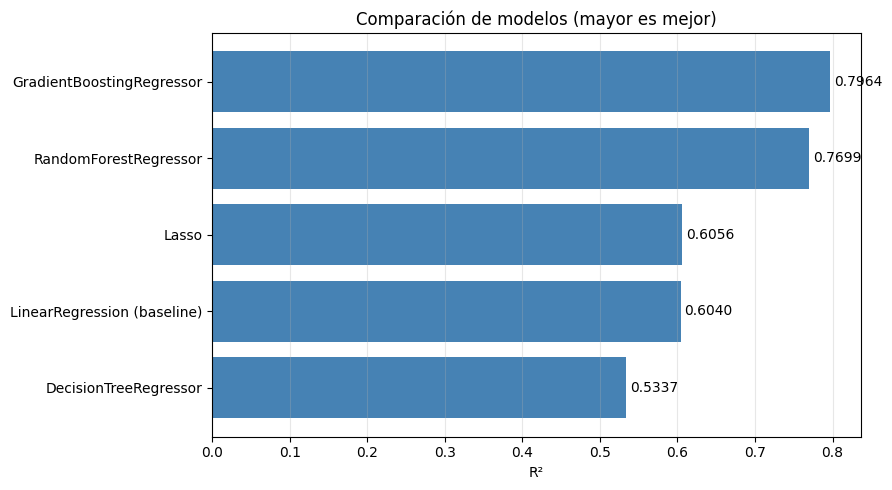

In [10]:
# Comparación visual del R2
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_resultados['modelo'], df_resultados['R2'], color='steelblue')
ax.set_xlabel('R²')
ax.set_title('Comparación de modelos (mayor es mejor)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_resultados['R2']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

## Resumen

Probamos varios algoritmos de regresión sobre los mismos datos. Los de conjunto suelen ganar a los lineales y al árbol simple, porque combinan muchos modelos en vez de confiar en uno solo.

En el cuaderno `03-optimizacion-modelos.ipynb` vamos a **afinar** el mejor de estos, ajustando sus hiperparámetros y preprocesando los datos.